In [3]:
import kagglehub
# Download latest version
path = kagglehub.dataset_download("thedevastator/unlock-profits-with-e-commerce-sales-data")
print("Path to dataset files:", path)

Resuming download from 4194304 bytes (2440506 bytes left)...
Resuming download to /Users/tmchq/.cache/kagglehub/datasets/thedevastator/unlock-profits-with-e-commerce-sales-data/2.archive (4194304/6634810) bytes left.


100%|██████████| 6.33M/6.33M [00:07<00:00, 328kB/s]

Extracting files...
Path to dataset files: /Users/tmchq/.cache/kagglehub/datasets/thedevastator/unlock-profits-with-e-commerce-sales-data/versions/2


In [4]:
import os
files = os.listdir(path)
print(files)

['Amazon Sale Report.csv', 'Cloud Warehouse Compersion Chart.csv', 'P  L March 2021.csv', 'May-2022.csv', 'Sale Report.csv', 'International sale Report.csv', 'Expense IIGF.csv']


In [20]:
import pandas as pd

df = pd.read_csv(path + '/Amazon Sale Report.csv', low_memory=False)
print(df.shape)
print(df.columns.tolist())
print(df.head())

(128975, 24)
['index', 'Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel ', 'ship-service-level', 'Style', 'SKU', 'Category', 'Size', 'ASIN', 'Courier Status', 'Qty', 'currency', 'Amount', 'ship-city', 'ship-state', 'ship-postal-code', 'ship-country', 'promotion-ids', 'B2B', 'fulfilled-by', 'Unnamed: 22']
   index             Order ID      Date                        Status  \
0      0  405-8078784-5731545  04-30-22                     Cancelled   
1      1  171-9198151-1101146  04-30-22  Shipped - Delivered to Buyer   
2      2  404-0687676-7273146  04-30-22                       Shipped   
3      3  403-9615377-8133951  04-30-22                     Cancelled   
4      4  407-1069790-7240320  04-30-22                       Shipped   

  Fulfilment Sales Channel  ship-service-level    Style              SKU  \
0   Merchant      Amazon.in           Standard   SET389   SET389-KR-NP-S   
1   Merchant      Amazon.in           Standard  JNE3781  JNE3781-KR-XXXL   
2     Amazon     

In [21]:
print(df.columns.tolist())
print(df.shape)

['index', 'Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel ', 'ship-service-level', 'Style', 'SKU', 'Category', 'Size', 'ASIN', 'Courier Status', 'Qty', 'currency', 'Amount', 'ship-city', 'ship-state', 'ship-postal-code', 'ship-country', 'promotion-ids', 'B2B', 'fulfilled-by', 'Unnamed: 22']
(128975, 24)


In [22]:
print(df.dtypes)
print("---")
print(df.isnull().sum())

index                   int64
Order ID                  str
Date                      str
Status                    str
Fulfilment                str
Sales Channel             str
ship-service-level        str
Style                     str
SKU                       str
Category                  str
Size                      str
ASIN                      str
Courier Status            str
Qty                     int64
currency                  str
Amount                float64
ship-city                 str
ship-state                str
ship-postal-code      float64
ship-country              str
promotion-ids             str
B2B                      bool
fulfilled-by              str
Unnamed: 22            object
dtype: object
---
index                     0
Order ID                  0
Date                      0
Status                    0
Fulfilment                0
Sales Channel             0
ship-service-level        0
Style                     0
SKU                       0
Category  

In [23]:

df = df.drop(columns=['Unnamed: 22', 'promotion-ids', 'fulfilled-by', 'index'])


df = df.dropna(subset=['Amount', 'currency'])


df['Date'] = pd.to_datetime(df['Date'])


print(df.shape)
print(df.isnull().sum())
print(df.dtypes)

(121180, 20)
Order ID                 0
Date                     0
Status                   0
Fulfilment               0
Sales Channel            0
ship-service-level       0
Style                    0
SKU                      0
Category                 0
Size                     0
ASIN                     0
Courier Status        5136
Qty                      0
currency                 0
Amount                   0
ship-city               31
ship-state              31
ship-postal-code        31
ship-country            31
B2B                      0
dtype: int64
Order ID                         str
Date                  datetime64[us]
Status                           str
Fulfilment                       str
Sales Channel                    str
ship-service-level               str
Style                            str
SKU                              str
Category                         str
Size                             str
ASIN                             str
Courier Status             

/var/folders/pw/qrzh_csj73jdk228b2n4_y2w0000gn/T/ipykernel_35425/3794657401.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'])


In [24]:
print(df.shape)
print(df['Date'].min(), df['Date'].max())
print(df['Status'].value_counts())
print(df['Category'].value_counts())

(121180, 20)
2022-03-31 00:00:00 2022-06-29 00:00:00
Status
Shipped                          77596
Shipped - Delivered to Buyer     28761
Cancelled                        10766
Shipped - Returned to Seller      1950
Shipped - Picked Up                973
Pending                            656
Pending - Waiting for Pick Up      281
Shipped - Returning to Seller      145
Shipped - Out for Delivery          35
Shipped - Rejected by Buyer         11
Shipped - Lost in Transit            5
Shipped - Damaged                    1
Name: count, dtype: int64
Category
Set              47042
kurta            46717
Western Dress    14704
Top              10165
Ethnic Dress      1093
Blouse             881
Bottom             420
Saree              155
Dupatta              3
Name: count, dtype: int64


In [35]:
print(f"Дубликатов: {df.duplicated().sum()}")
print(f"Дубликатов по Order ID: {df['Order ID'].duplicated().sum()}")

Дубликатов: 3
Дубликатов по Order ID: 8150


In [36]:
# Удаляем 3 полных дубликата
df = df.drop_duplicates()
print(f"После удаления дубликатов: {df.shape}")

# Смотрим почему Order ID повторяются
dup_orders = df[df['Order ID'].duplicated(keep=False)].sort_values('Order ID')
print(dup_orders[['Order ID', 'Status', 'SKU', 'Qty', 'Amount']].head(10))

После удаления дубликатов: (121177, 20)
                   Order ID                        Status                SKU  \
78939   171-0012693-2893106                     Cancelled      NW015-TP-PJ-S   
78938   171-0012693-2893106                     Cancelled      NW030-TP-PJ-S   
91475   171-0014231-7760344                       Pending  SET342-KR-NP-N-XS   
91476   171-0014231-7760344                       Pending       J0224-SKD-XS   
24516   171-0015435-1981904                       Shipped       JNE3794-KR-L   
24515   171-0015435-1981904                       Shipped       JNE3611-KR-L   
99358   171-0019960-6156301                       Shipped  SET331-KR-NP-XXXL   
99357   171-0019960-6156301                       Shipped  SET334-KR-NP-XXXL   
123553  171-0031114-0715560  Shipped - Delivered to Buyer     JNE3401-KR-XXL   
123554  171-0031114-0715560  Shipped - Delivered to Buyer      JNE3425-KR-XL   

        Qty   Amount  
78939     0   477.14  
78938     0   538.10  
91475     

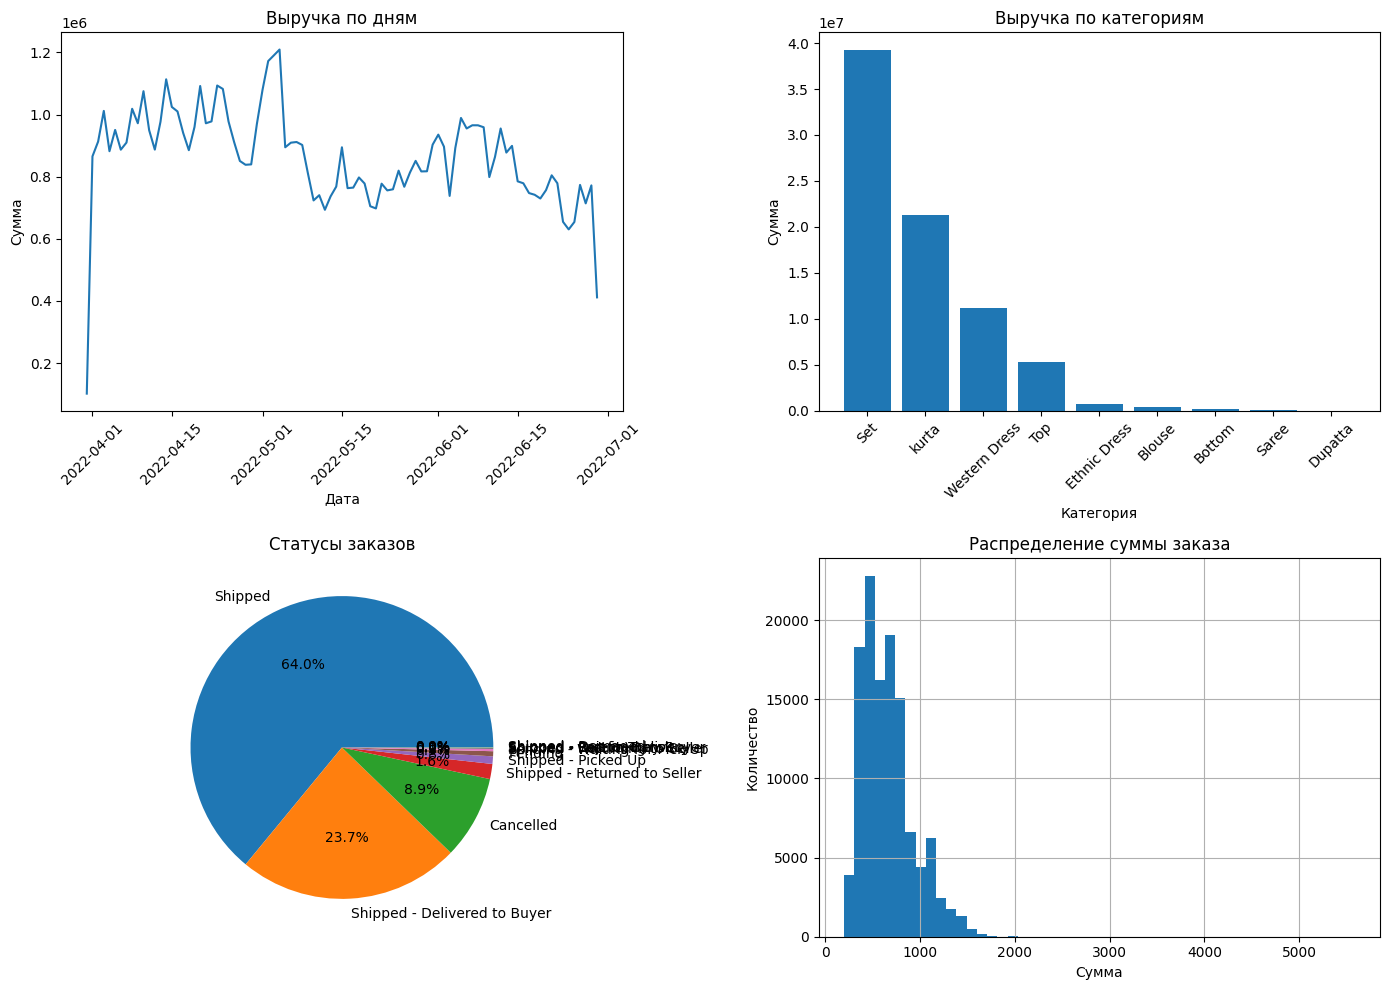

In [25]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Продажи по дням
daily_sales = df.groupby('Date')['Amount'].sum()
axes[0,0].plot(daily_sales.index, daily_sales.values)
axes[0,0].set_title('Выручка по дням')
axes[0,0].set_xlabel('Дата')
axes[0,0].set_ylabel('Сумма')
axes[0,0].tick_params(axis='x', rotation=45)

# 2. Топ категорий по выручке
cat_revenue = df.groupby('Category')['Amount'].sum().sort_values(ascending=False)
axes[0,1].bar(cat_revenue.index, cat_revenue.values)
axes[0,1].set_title('Выручка по категориям')
axes[0,1].set_xlabel('Категория')
axes[0,1].set_ylabel('Сумма')
axes[0,1].tick_params(axis='x', rotation=45)

# 3. Распределение статусов
status_counts = df['Status'].value_counts()
axes[1,0].pie(status_counts.values, labels=status_counts.index, autopct='%1.1f%%')
axes[1,0].set_title('Статусы заказов')

# 4. Распределение суммы заказа
df[df['Amount'] > 0]['Amount'].hist(bins=50, ax=axes[1,1])
axes[1,1].set_title('Распределение суммы заказа')
axes[1,1].set_xlabel('Сумма')
axes[1,1].set_ylabel('Количество')

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150)
plt.show()


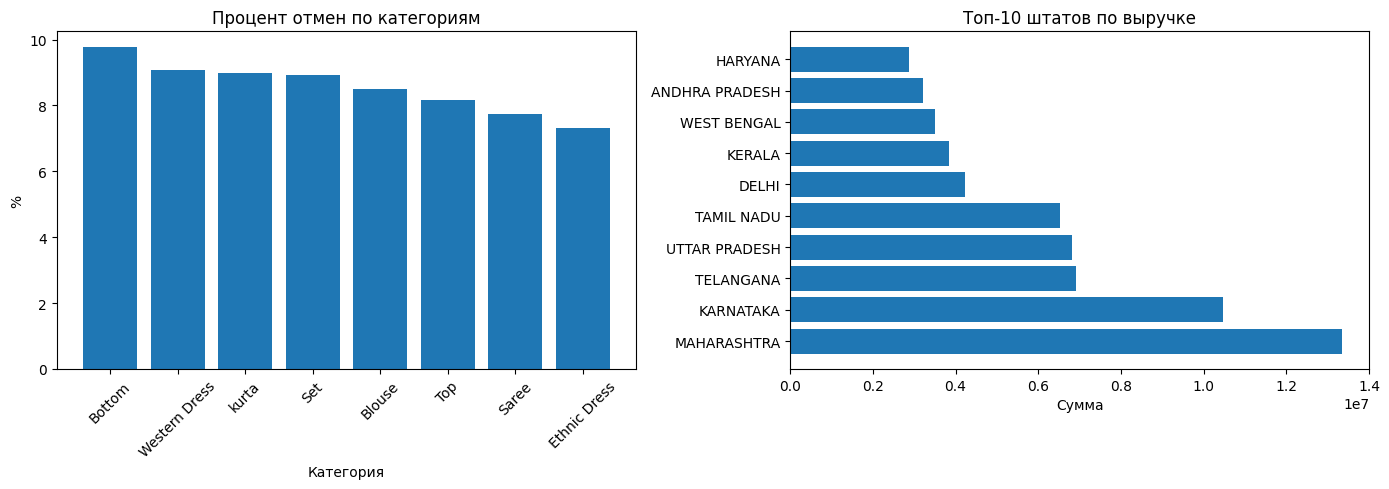

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Отмены по категориям
cancelled = df[df['Status'] == 'Cancelled'].groupby('Category').size()
total = df.groupby('Category').size()
cancel_rate = (cancelled / total * 100).sort_values(ascending=False)

axes[0].bar(cancel_rate.index, cancel_rate.values)
axes[0].set_title('Процент отмен по категориям')
axes[0].set_xlabel('Категория')
axes[0].set_ylabel('%')
axes[0].tick_params(axis='x', rotation=45)

# Выручка по штатам топ-10
top_states = df.groupby('ship-state')['Amount'].sum().sort_values(ascending=False).head(10)
axes[1].barh(top_states.index, top_states.values)
axes[1].set_title('Топ-10 штатов по выручке')
axes[1].set_xlabel('Сумма')

plt.tight_layout()
plt.savefig('eda_deep.png', dpi=150)
plt.show()

In [27]:
# Выбросы в Amount
Q25 = df['Amount'].quantile(0.25)
Q75 = df['Amount'].quantile(0.75)
IQR = Q75 - Q25
outliers = df[df['Amount'] > Q3 + 1.5 * IQR]

print(f"Всего заказов: {len(df)}")
print(f"Выбросов по сумме: {len(outliers)} ({len(outliers)/len(df)*100:.1f}%)")
print(f"Средний чек: {df['Amount'].mean():.0f}")
print(f"Медианный чек: {df['Amount'].median():.0f}")
print(f"Средний чек без выбросов: {df[df['Amount'] <= Q75 + 1.5*IQR]['Amount'].mean():.0f}")
print(f"\nB2B vs B2C:")
print(df.groupby('B2B')['Amount'].agg(['mean', 'count']))

Всего заказов: 121180
Выбросов по сумме: 3600 (3.0%)
Средний чек: 649
Медианный чек: 605
Средний чек без выбросов: 624

B2B vs B2C:
             mean   count
B2B                      
False  648.191807  120337
True   701.329526     843


In [28]:
print(df[df['Status'] == 'Cancelled']['Fulfilment'].value_counts())
print("---")
print(df.groupby('Fulfilment')['Status'].apply(lambda x: (x == 'Cancelled').sum() / len(x) * 100).round(2))
print("---")
print(df.groupby('Courier Status')['Status'].apply(lambda x: (x == 'Cancelled').sum() / len(x) * 100).round(2))

Fulfilment
Amazon      5630
Merchant    5136
Name: count, dtype: int64
---
Fulfilment
Amazon       6.73
Merchant    13.68
Name: Status, dtype: float64
---
Courier Status
Shipped       0.00
Unshipped    85.86
Name: Status, dtype: float64


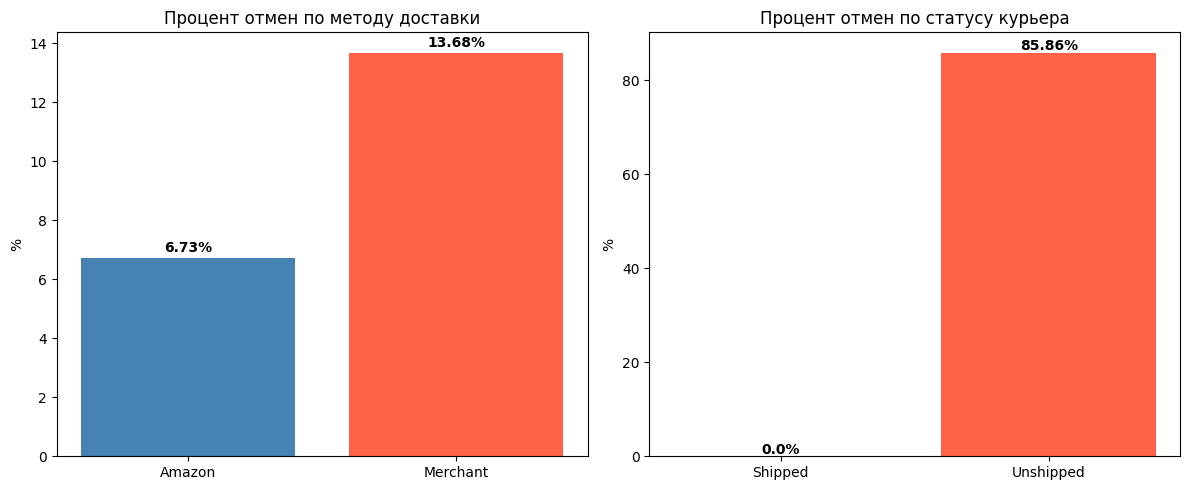

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Отмены по методу доставки
fulfil_cancel = df.groupby('Fulfilment')['Status'].apply(
    lambda x: (x == 'Cancelled').sum() / len(x) * 100
).round(2)
axes[0].bar(fulfil_cancel.index, fulfil_cancel.values, color=['steelblue', 'tomato'])
axes[0].set_title('Процент отмен по методу доставки')
axes[0].set_ylabel('%')
for i, v in enumerate(fulfil_cancel.values):
    axes[0].text(i, v + 0.2, f'{v}%', ha='center', fontweight='bold')

# Отмены по статусу курьера
courier_cancel = df.groupby('Courier Status')['Status'].apply(
    lambda x: (x == 'Cancelled').sum() / len(x) * 100
).round(2)
axes[1].bar(courier_cancel.index, courier_cancel.values, color=['steelblue', 'tomato'])
axes[1].set_title('Процент отмен по статусу курьера')
axes[1].set_ylabel('%')
for i, v in enumerate(courier_cancel.values):
    axes[1].text(i, v + 0.5, f'{v}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('eda_cancellations.png', dpi=150)
plt.show()

In [30]:
# Сводная таблица по категориям
cat_summary = df.groupby('Category').agg(
    Заказов=('Order ID', 'count'),
    Выручка=('Amount', 'sum'),
    Средний_чек=('Amount', 'mean'),
    Медиана_чека=('Amount', 'median'),
    Отмен_пct=('Status', lambda x: (x == 'Cancelled').sum() / len(x) * 100)
).round(2)

cat_summary['Выручка'] = cat_summary['Выручка'].round(0)
cat_summary['Доля_выручки_%'] = (cat_summary['Выручка'] / cat_summary['Выручка'].sum() * 100).round(1)
cat_summary = cat_summary.sort_values('Выручка', ascending=False)

print(cat_summary.to_string())

               Заказов     Выручка  Средний_чек  Медиана_чека  Отмен_пct  Доля_выручки_%
Category                                                                                
Set              47042  39204124.0       833.39        788.00       8.93            49.9
kurta            46717  21299547.0       455.93        435.00       8.98            27.1
Western Dress    14704  11216073.0       762.79        744.00       9.08            14.3
Top              10165   5347792.0       526.10        519.05       8.16             6.8
Ethnic Dress      1093    791218.0       723.90        837.00       7.32             1.0
Blouse             881    458408.0       520.33        545.00       8.51             0.6
Bottom             420    150668.0       358.73        345.00       9.76             0.2
Saree              155    123934.0       799.57        791.00       7.74             0.2
Dupatta              3       915.0       305.00        305.00       0.00             0.0


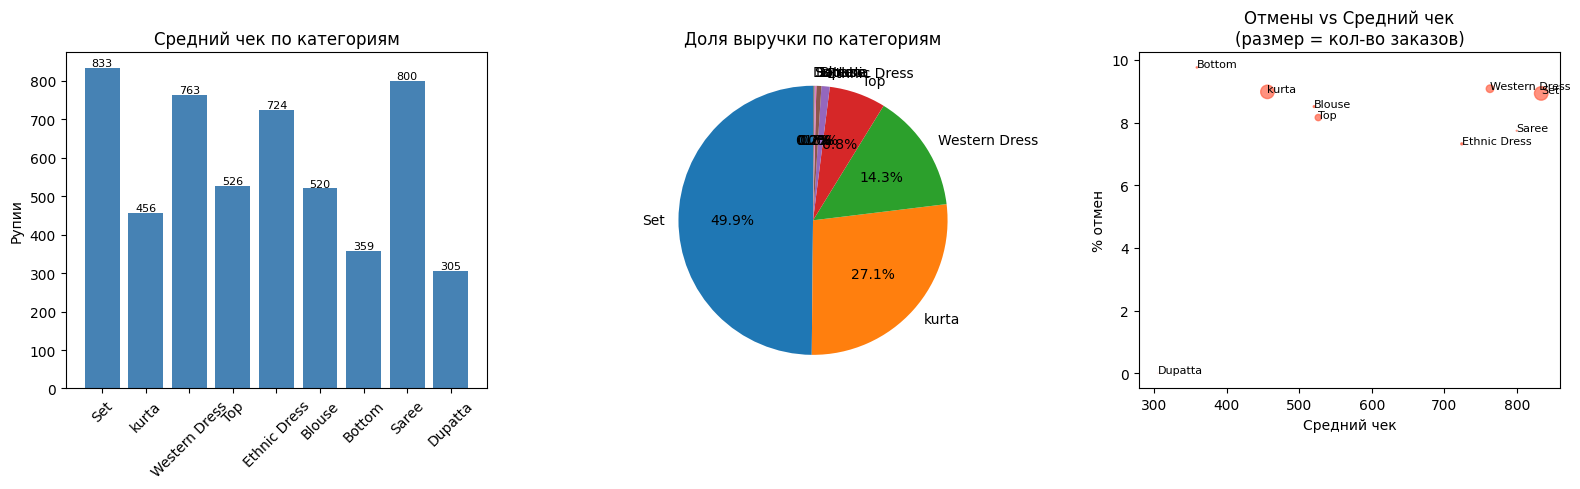

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

categories = cat_summary.index

# 1. Средний чек по категориям
axes[0].bar(categories, cat_summary['Средний_чек'], color='steelblue')
axes[0].set_title('Средний чек по категориям')
axes[0].set_ylabel('Рупии')
axes[0].tick_params(axis='x', rotation=45)
for cat in categories:
    axes[0].text(categories.get_loc(cat), cat_summary['Средний_чек'][cat] + 5,
                 f'{cat_summary["Средний_чек"][cat]:.0f}', ha='center', fontsize=8)

# 2. Доля выручки
axes[1].pie(cat_summary['Доля_выручки_%'],
            labels=categories,
            autopct='%1.1f%%',
            startangle=90)
axes[1].set_title('Доля выручки по категориям')

# 3. Отмены vs средний чек
axes[2].scatter(cat_summary['Средний_чек'],
                cat_summary['Отмен_пct'],
                s=cat_summary['Заказов']/500,
                alpha=0.7, color='tomato')
for cat in categories:
    axes[2].annotate(cat,
                    (cat_summary['Средний_чек'][cat], cat_summary['Отмен_пct'][cat]),
                    fontsize=8, ha='left')
axes[2].set_title('Отмены vs Средний чек\n(размер = кол-во заказов)')
axes[2].set_xlabel('Средний чек')
axes[2].set_ylabel('% отмен')

plt.tight_layout()
plt.savefig('eda_categories.png', dpi=150)
plt.show()

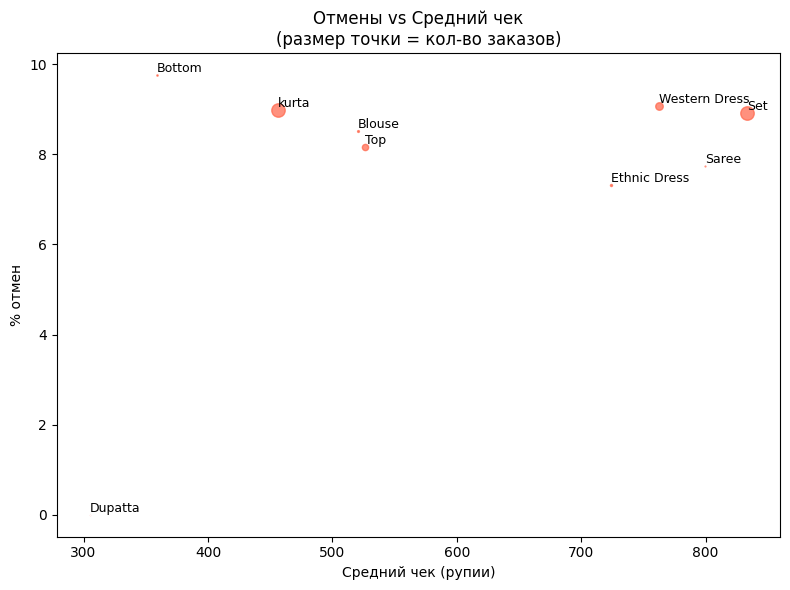

In [34]:
fig, ax = plt.subplots(figsize=(8, 6))

for cat in categories:
    ax.scatter(cat_summary['Средний_чек'][cat],
               cat_summary['Отмен_пct'][cat],
               s=cat_summary['Заказов'][cat]/500,
               alpha=0.7, color='tomato')
    ax.annotate(cat,
                (cat_summary['Средний_чек'][cat], cat_summary['Отмен_пct'][cat]),
                fontsize=9, ha='left', va='bottom')

ax.set_title('Отмены vs Средний чек\n(размер точки = кол-во заказов)')
ax.set_xlabel('Средний чек (рупии)')
ax.set_ylabel('% отмен')

plt.tight_layout()
plt.savefig('eda_scatter.png', dpi=150)
plt.show()